### Import Libs

In [2]:
import ast
import os
import networkx as nx
import community as community_louvain
from collections import defaultdict
from matplotlib import pyplot as plt
import seaborn as sns
import nbformat
from nbconvert import PythonExporter
from pyvis.network import Network
from tqdm import tqdm

In [3]:
class CallGraphVisitor(ast.NodeVisitor):
    def __init__(self, filepath, global_functions, base_dir):
        self.filepath = os.path.relpath(filepath, base_dir)
        self.base_dir = base_dir
        self.global_functions = global_functions

        self.current_function = None
        self.current_class = None
        self.calls = []
        self.functions = []
        self.imports = {}  # alias -> file path

    # --- Import tracking ---
    def visit_Import(self, node):
        for alias in node.names:
            module_name = alias.name  # e.g., "utils.helper"
            asname = alias.asname or module_name.split(".")[-1]
            module_path = self._resolve_module_to_path(module_name)
            if module_path:
                self.imports[asname] = module_path
        self.generic_visit(node)

    def visit_ImportFrom(self, node):
        # e.g., from example02 import y
        if node.module:
            module_name = node.module
            module_path = self._resolve_module_to_path(module_name)
            for alias in node.names:
                asname = alias.asname or alias.name
                self.imports[asname] = module_path
        self.generic_visit(node)

    def _resolve_module_to_path(self, module_name):
        """Convert module name to file path if exists in the project."""
        path_guess = os.path.join(self.base_dir, *module_name.split(".")) + ".py"
        if os.path.exists(path_guess):
            return os.path.relpath(path_guess, self.base_dir)
        return None

    # --- Class and function tracking ---
    def visit_ClassDef(self, node):
        prev_class = self.current_class
        self.current_class = node.name
        self.generic_visit(node)
        self.current_class = prev_class

    def visit_FunctionDef(self, node):
        if self.current_class:
            full_name = f"{self.filepath}:{self.current_class}.{node.name}"
            short_name = f"{self.current_class}.{node.name}"
        else:
            full_name = f"{self.filepath}:{node.name}"
            short_name = node.name

        self.functions.append({
            "full_name": full_name,
            "short_name": short_name,
            "class_name": self.current_class,
            "filepath": self.filepath,
            "lineno": node.lineno,
            "col_offset": node.col_offset
        })

        self.global_functions.setdefault(short_name, []).append(full_name)

        prev_function = self.current_function
        self.current_function = full_name
        self.generic_visit(node)
        self.current_function = prev_function

    # --- Call tracking ---
    def visit_Call(self, node):
        # If not inside a function, treat it as a top-level (module) call
        caller = self.current_function or f"{self.filepath}:<module>"

        callee_full = None

        # Case 1: direct call like y()
        if isinstance(node.func, ast.Name):
            name = node.func.id
            if name in self.imports and self.imports[name]:
                callee_file = self.imports[name]
                matches = self.global_functions.get(name, [])
                if matches:
                    callee_full = matches[0].replace(matches[0].split(":")[0], callee_file)
                else:
                    callee_full = f"{callee_file}:{name}"
            elif name in self.global_functions:
                callee_full = self.global_functions[name][0]
            else:
                callee_full = name

        # Case 2: attribute call like mod.func()
        elif isinstance(node.func, ast.Attribute):
            value = getattr(node.func.value, "id", None)
            attr = node.func.attr
            if value and value in self.imports and self.imports[value]:
                callee_file = self.imports[value]
                callee_full = f"{callee_file}:{attr}"
            else:
                callee_full = attr

        if callee_full:
            self.calls.append((caller, callee_full))

        self.generic_visit(node)


### Function Cllector

In [4]:
class FunctionCollector(ast.NodeVisitor):
    """Collect all top-level functions and class methods."""
    def __init__(self, filename):
        self.filename = filename
        self.functions = {}  # {full_func_name: node}
        self.class_defs = {}  # {full_class_name: node}
        self.current_class = None

    def visit_ClassDef(self, node):
        class_name = f"{self.filename}:{node.name}"
        self.class_defs[class_name] = node

        prev_class = self.current_class
        self.current_class = node.name
        self.generic_visit(node)
        self.current_class = prev_class

    def visit_FunctionDef(self, node):
        if self.current_class:
            # Class method
            full_name = f"{self.filename}:{self.current_class}.{node.name}"
        else:
            # Top-level function
            full_name = f"{self.filename}:{node.name}"
        self.functions[full_name] = node
        self.generic_visit(node)

def get_py_files(root_dir):
    py_files = []
    for root, _, files in os.walk(root_dir):
        for file in files:
            if file.endswith(".py"):
                py_files.append(os.path.join(root, file))
    return py_files

def get_ipynb_files(root_dir):
    ipynb_files = []
    for root, _, files in os.walk(root_dir):
        for file in files:
            if file.endswith(".ipynb"):
                ipynb_files.append(os.path.join(root, file))
    return ipynb_files

def build_call_graph(root_dir):
    global_functions = {}
    G = nx.DiGraph()
    py_files = get_py_files(root_dir)
    ipynb_files = get_ipynb_files(root_dir)
    for file in py_files:
        with open(file, "r", encoding="utf-8") as f:
            try:
                tree = ast.parse(f.read(), filename=file)
                visitor = CallGraphVisitor(file, global_functions, root_dir)
                visitor.visit(tree)
                for caller, callee in visitor.calls:
                    if ":" not in callee:
                        continue
                    G.add_edge(caller, callee)
            except Exception as e:
                print(f"Error parsing {file}: {e}")
    for file in ipynb_files:
        if file.endswith(".ipynb"):
            try:
                with open(file, "r", encoding="utf-8") as f:
                    nb = nbformat.read(f, as_version=4)
                    exporter = PythonExporter()
                    source, _ = exporter.from_notebook_node(nb)
                    tree = ast.parse(source, filename=file)
                    visitor = CallGraphVisitor(file, global_functions, root_dir)
                    visitor.visit(tree)
                    for caller, callee in visitor.calls:
                        if ":" not in callee:
                            continue
                        G.add_edge(caller, callee)
            except Exception as e:
                print(f"Error parsing {file}: {e}")
    return {'graph':G,'py_count':len(py_files),'ipynb_count':len(ipynb_files)}

def collect_all_definitions(root_dir):
    """Return dicts for functions and classes with their AST nodes."""
    all_functions = {}
    all_classes = {}
    for file in get_py_files(root_dir):
        with open(file, "r", encoding="utf-8") as f:
            try:
                tree = ast.parse(f.read(), filename=file)
                collector = FunctionCollector(file)
                collector.visit(tree)
                all_functions.update(collector.functions)
                all_classes.update(collector.class_defs)
            except Exception as e:
                print(f"Error parsing {file}: {e}")
    for file in get_ipynb_files(root_dir):
        if file.endswith(".ipynb"):
            try:
                with open(file, "r", encoding="utf-8") as f:
                    nb = nbformat.read(f, as_version=4)
                    exporter = PythonExporter()
                    source, _ = exporter.from_notebook_node(nb)
                    tree = ast.parse(source, filename=file)
                    collector = FunctionCollector(file)
                    collector.visit(tree)
                    all_functions.update(collector.functions)
                    all_classes.update(collector.class_defs)
            except Exception as e:
                print(f"Error parsing {file}: {e}")
    return all_functions, all_classes

# --- Refactor: split into compute_clusters and save_clusters ---

def compute_clusters(repo_path,random_state = 42,resolution=1):
    """
    Analyze the repository at `repo_path` and compute clustering of call graph nodes.

    Returns:
        clusters: dict[int, list[str]]  -- mapping cluster_id -> list of node names
        all_functions: dict[str, ast.AST] -- mapping function full names to AST nodes
        all_classes: dict[str, ast.AST]   -- mapping class full names to AST nodes
        output_dir: str                       -- suggested output directory for saving clusters
    """
    output_dir = f"result/repo_callgraph_clusters/{repo_path.split('/')[-1]}"
    os.makedirs(output_dir, exist_ok=True)

    # Build the call graph and partition it
    graph_builder = build_call_graph(repo_path)
    graph_undirected = graph_builder['graph'].to_undirected()
    py_count = graph_builder['py_count']
    ipynb_count = graph_builder['ipynb_count']
    

    # Collect all functions and classes
    all_functions, all_classes = collect_all_definitions(repo_path)

    partition = community_louvain.best_partition(graph_undirected,random_state=random_state,resolution=resolution)
    # Build cluster mapping (cluster_id -> list of nodes)
    clusters = defaultdict(list)
    for node, cluster_id in partition.items():
        clusters[cluster_id].append(node)

    # partition = list(nx.connected_components(graph_undirected))
    # for cluster_id,node in enumerate(partition):
    #     clusters[cluster_id].append(node)
    return clusters, all_functions, all_classes, output_dir, py_count, ipynb_count


def save_clusters(clusters, all_functions, all_classes, output_dir,root_dir=""):
    """
    Save computed clusters into Python files under `output_dir`.

    This function writes one file per cluster and attempts to unparse
    class and function AST nodes back to source code. It avoids duplicate
    class writes when multiple class methods appear in the same cluster.
    """
    for cluster_id, nodes in clusters.items():
        file_path = os.path.join(output_dir, f"cluster_{cluster_id}.py")
        written_classes = set()  # Avoid duplicate class writing
        written_functions = set()

        with open(file_path, "w", encoding="utf-8") as out:
            out.write(f"# Cluster {cluster_id}\n\n")

            for node_name in nodes:
                node_name = root_dir + "/" + node_name
                # If it's a class method, include the entire class
                for class_name, class_node in all_classes.items():
                    if node_name.startswith(class_name + ".") and class_name not in written_classes:
                        try:
                            source = ast.unparse(class_node)
                            # print("="*30+f"  {class_name}  "+"="*30)
                            # print(source)
                            # print("="*100)
                            out.write(source + "\n\n")
                            written_classes.add(class_name)
                        except Exception:
                            out.write(f"# Could not unparse {class_name}\n\n")

                # If it's a standalone function
                if node_name in all_functions and node_name not in written_functions:
                    is_written = False
                    for written_class in written_classes:
                        if node_name.startswith(written_class+'.'):
                            is_written=True
                            break
                    if not is_written:
                        try:
                            source = ast.unparse(all_functions[node_name])
                            # print("+"*30+f"  {node_name}  "+"+"*30)
                            # print(source)
                            # print("="*100)
                            out.write(source + "\n\n")
                        except Exception:
                            out.write(f"# Could not unparse {node_name}\n\n")

        print(f"✅ cluster_{cluster_id}.py saved with {len(nodes)} entries")

    print("\nAll cluster code files are in:", output_dir)


def cluster_and_save_code(repo_path):
    """Compatibility wrapper that computes clusters and saves them to files."""
    clusters, all_functions, all_classes, output_dir, py_count, ipynb_count = compute_clusters(repo_path,resolution=2,random_state=1)
    save_clusters(clusters, all_functions, all_classes, output_dir,root_dir=repo_path)


### Graph Generator

In [218]:
def generate_html_graph(repo_dir, out_dir='./result/graph-network'):
    graph = build_call_graph(repo_dir)
    G = graph['graph']
    if G.number_of_nodes() == 0:
        print(repo_dir)
    # Create PyVis network
    net = Network(
        height="100vh",
        width="100%",
        directed=True,
        bgcolor="#FFFFFF",
        font_color="black"
    )

    # Physics engine (smooth layout)
    net.barnes_hut(
        gravity=-5000,
        spring_length=150,
        central_gravity=0.25,
        spring_strength=0.02,
    )

    # High-contrast colors for files
    colors = [
        "#EF476F", "#06D6A0", "#118AB2", "#FFD166",
        "#073B4C", "#9B5DE5", "#F15BB5", "#00BBF9",
        "#00F5D4", "#FEE440", "#FF7D00", "#FF006E"
    ]

    # Map file => color
    file_colors = {}
    color_index = 0

    def get_color(node):
        nonlocal color_index
        file = node.split(":")[0]
        if file not in file_colors:
            file_colors[file] = colors[color_index % len(colors)]
            color_index += 1
        return file_colors[file]

    # Add nodes
    for node in G.nodes():
        file, func = node.split(":", 1)
        degree = G.degree(node)
        size = 12 + degree * 2

        net.add_node(
            node,
            label=func,
            title=f"<b>File:</b> {file}<br><b>Function:</b> {func}",
            color=get_color(node),
            size=size,
            shape="dot",
        )

    # Add edges with arrow heads
    for u, v in G.edges():
        net.add_edge(
            u,
            v,
            arrows="to",
            color="#666666",
            width=1.4
        )

    net.show_buttons(filter_=["physics"])

    # Write original HTML
    os.makedirs(out_dir, exist_ok=True)
    html_path = f"{out_dir}/{repo_dir.split('/')[-1]}.html"
    net.write_html(html_path)

    # -------------------------------
    # 🔥 Patch HTML to remove local PyVis JS
    # -------------------------------
    html = open(html_path, "r", encoding="utf-8").read()

    # Remove local script references
    html = html.replace('<script src="lib/bindings/utils.js"></script>', "")
    html = html.replace('<script src="lib/bindings/vis-network.min.js"></script>', "")
    html = html.replace('<script src="lib/bindings/vis.js"></script>', "")

    # Add CDN version of vis-network
    cdn_script = """
<script src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
"""

    html = html.replace("</body>", cdn_script + "\n</body>")

    # Save patched HTML
    with open(html_path, "w", encoding="utf-8") as f:
        f.write(html)



In [6]:
path = "/home/hasinthaka/Documents/Experiments/Pattern Extraction - From Repos/repos/cloned_repos"
folders = [name for name in os.listdir(path) if os.path.isdir(os.path.join(path, name))]

In [ ]:
for folder in tqdm(folders,desc="Generation Graphs:",ncols=80):
    generate_html_graph(path+"/"+folder)

In [7]:
for folder in tqdm(folders,desc="Generation Clusters:",ncols=80):
    cluster_and_save_code(path+"/"+folder)

/home/hasinthaka/Documents/Experiments/Pattern Extraction - From Repos/repos/cloned_repos/evadb/evadb/utils/s3_utils.py:45: SyntaxWarning: invalid escape sequence '\*'
  if re.search(re.sub("\*", ".*", regex_key), obj.key):  # noqa: W605


✅ cluster_0.py saved with 4 entries
✅ cluster_2.py saved with 47 entries
✅ cluster_4.py saved with 90 entries
✅ cluster_39.py saved with 34 entries
✅ cluster_6.py saved with 20 entries
✅ cluster_66.py saved with 24 entries
✅ cluster_8.py saved with 15 entries
✅ cluster_9.py saved with 43 entries
✅ cluster_10.py saved with 7 entries
✅ cluster_11.py saved with 53 entries
✅ cluster_12.py saved with 76 entries
✅ cluster_13.py saved with 17 entries
✅ cluster_14.py saved with 55 entries
✅ cluster_56.py saved with 87 entries
✅ cluster_16.py saved with 196 entries
✅ cluster_24.py saved with 58 entries
✅ cluster_18.py saved with 28 entries
✅ cluster_19.py saved with 33 entries
✅ cluster_97.py saved with 66 entries
✅ cluster_70.py saved with 22 entries
✅ cluster_22.py saved with 3 entries
✅ cluster_23.py saved with 2 entries
✅ cluster_25.py saved with 3 entries
✅ cluster_26.py saved with 2 entries
✅ cluster_27.py saved with 2 entries
✅ cluster_28.py saved with 2 entries
✅ cluster_29.py saved wit

Generation Clusters::  62%|████████████▉        | 47/76 [01:55<03:23,  7.03s/it]

✅ cluster_89.py saved with 25 entries
✅ cluster_90.py saved with 7 entries
✅ cluster_94.py saved with 4 entries
✅ cluster_95.py saved with 2 entries
✅ cluster_101.py saved with 2 entries
✅ cluster_114.py saved with 2 entries
✅ cluster_1.py saved with 2 entries
✅ cluster_5.py saved with 2 entries
✅ cluster_15.py saved with 2 entries
✅ cluster_17.py saved with 2 entries
✅ cluster_20.py saved with 7 entries
✅ cluster_21.py saved with 2 entries
✅ cluster_30.py saved with 10 entries
✅ cluster_33.py saved with 4 entries
✅ cluster_34.py saved with 6 entries
✅ cluster_36.py saved with 18 entries
✅ cluster_40.py saved with 2 entries
✅ cluster_43.py saved with 2 entries
✅ cluster_46.py saved with 2 entries
✅ cluster_47.py saved with 2 entries
✅ cluster_48.py saved with 2 entries
✅ cluster_50.py saved with 5 entries
✅ cluster_52.py saved with 2 entries
✅ cluster_55.py saved with 3 entries
✅ cluster_58.py saved with 2 entries
✅ cluster_61.py saved with 3 entries

All cluster code files are in: res

/home/hasinthaka/Documents/Experiments/Pattern Extraction - From Repos/repos/cloned_repos/nuplan-devkit/tutorials/nuplan_framework.ipynb:349: SyntaxWarning: invalid escape sequence '\='
  "      </iframe>\n",
/home/hasinthaka/Documents/Experiments/Pattern Extraction - From Repos/repos/cloned_repos/nuplan-devkit/tutorials/nuplan_framework.ipynb:349: SyntaxWarning: invalid escape sequence '\='
  "      </iframe>\n",


...

✅ cluster_0.py saved with 8 entries
✅ cluster_4.py saved with 2 entries
✅ cluster_1.py saved with 2 entries
✅ cluster_3.py saved with 9 entries
✅ cluster_2.py saved with 2 entries

All cluster code files are in: result/repo_callgraph_clusters/Octopii
✅ cluster_0.py saved with 5 entries
✅ cluster_1.py saved with 3 entries
✅ cluster_2.py saved with 3 entries

All cluster code files are in: result/repo_callgraph_clusters/multi-class-text-classification-cnn


Generation Clusters::  99%|████████████████████▋| 75/76 [03:32<00:02,  2.24s/it]

✅ cluster_0.py saved with 11 entries
✅ cluster_1.py saved with 7 entries
✅ cluster_2.py saved with 5 entries
✅ cluster_6.py saved with 7 entries
✅ cluster_5.py saved with 2 entries
✅ cluster_7.py saved with 3 entries
✅ cluster_8.py saved with 6 entries
✅ cluster_9.py saved with 3 entries
✅ cluster_10.py saved with 2 entries
✅ cluster_11.py saved with 2 entries
✅ cluster_12.py saved with 6 entries
✅ cluster_3.py saved with 6 entries
✅ cluster_4.py saved with 2 entries

All cluster code files are in: result/repo_callgraph_clusters/deep_recommenders


/home/hasinthaka/Documents/Experiments/Pattern Extraction - From Repos/repos/cloned_repos/clai/clai/server/plugins/manpage_agent/webapp/train_sklearn_agent.py:20: SyntaxWarning: invalid escape sequence '\s'
  PATTERN_SPACES = re.compile("\s+")
/home/hasinthaka/Documents/Experiments/Pattern Extraction - From Repos/repos/cloned_repos/clai/clai/server/plugins/manpage_agent/webapp/train_sklearn_agent.py:20: SyntaxWarning: invalid escape sequence '\s'
  PATTERN_SPACES = re.compile("\s+")
Generation Clusters:: 100%|█████████████████████| 76/76 [03:33<00:00,  2.80s/it]

✅ cluster_4.py saved with 49 entries
✅ cluster_2.py saved with 14 entries
✅ cluster_3.py saved with 28 entries
✅ cluster_7.py saved with 1 entries
✅ cluster_8.py saved with 19 entries
✅ cluster_9.py saved with 7 entries
✅ cluster_10.py saved with 3 entries
✅ cluster_11.py saved with 2 entries
✅ cluster_12.py saved with 10 entries
✅ cluster_13.py saved with 17 entries
✅ cluster_14.py saved with 8 entries
✅ cluster_15.py saved with 45 entries
✅ cluster_16.py saved with 17 entries
✅ cluster_17.py saved with 18 entries
✅ cluster_18.py saved with 3 entries
✅ cluster_19.py saved with 12 entries
✅ cluster_20.py saved with 2 entries
✅ cluster_21.py saved with 2 entries
✅ cluster_34.py saved with 33 entries
✅ cluster_24.py saved with 26 entries
✅ cluster_25.py saved with 5 entries
✅ cluster_26.py saved with 5 entries
✅ cluster_27.py saved with 9 entries
✅ cluster_29.py saved with 3 entries
✅ cluster_31.py saved with 3 entries
✅ cluster_33.py saved with 2 entries
✅ cluster_35.py saved with 6 ent

In [ ]:
cluster_and_save_code("./ai-goat")

In [9]:
# repo_dir = "./monkey-net"
def plot_cluster_size_distribution(repo_dir):
    clusters, all_functions, all_classes, output_dir, py_count, ipynb_count = compute_clusters(repo_dir,resolution=2,random_state=1)
    print("Summary:")
    print(" - Repository analyzed".ljust(26)+':', repo_dir.split('/')[-1])
    print(" - Total Python files".ljust(26)+':', py_count)
    print(" - Total Jupyter notebooks".ljust(26)+':', ipynb_count)
    print(" - Functions/Methods found".ljust(26)+':', len(all_functions))
    print(" - Classes found".ljust(26)+':', len(all_classes))
    print(" - Clusters found".ljust(26)+':', len(clusters))
    cluster_and_save_code(repo_dir)
    plt.figure(figsize=(10, 6))
    sns.barplot(y=[(len(clusters[cluster])) for cluster in clusters.keys()],
                x=list(clusters.keys()))
    plt.title(f"Cluster Size Distribution for {repo_dir.split('/')[-1]}")
    plt.ylabel("Number of Functions/Methods in Cluster")
    plt.xlabel("Cluster Number")
    plt.show()

../../repos/cloned_repos/HuixiangDou/huixiangdou/primitive/splitter.py:270: SyntaxWarning: invalid escape sequence '\.'
  '\n\n', '\n', '。|！|？', '\.\s|\!\s|\?\s', '；|;\s', '，|,\s'
../../repos/cloned_repos/HuixiangDou/huixiangdou/primitive/splitter.py:270: SyntaxWarning: invalid escape sequence '\s'
  '\n\n', '\n', '。|！|？', '\.\s|\!\s|\?\s', '；|;\s', '，|,\s'
../../repos/cloned_repos/HuixiangDou/huixiangdou/primitive/splitter.py:270: SyntaxWarning: invalid escape sequence '\s'
  '\n\n', '\n', '。|！|？', '\.\s|\!\s|\?\s', '；|;\s', '，|,\s'
../../repos/cloned_repos/HuixiangDou/huixiangdou/services/prompt.py:6: SyntaxWarning: invalid escape sequence '\('
  INTENTION_TEMPLATE_CN = """你是一个文本专家，擅长对句子进行语义角色标注、情感分析和意图识别。
../../repos/cloned_repos/HuixiangDou/huixiangdou/services/prompt.py:56: SyntaxWarning: invalid escape sequence '\('
  INTENTION_TEMPLATE_EN = '''You are a text expert proficient in semantic role labeling, sentiment analysis, and intent recognition for sentences.
../../repos/cloned_

Summary:
 - Repository analyzed    : HuixiangDou
 - Total Python files     : 155
 - Total Jupyter notebooks: 0
 - Functions/Methods found: 570
 - Classes found          : 130
 - Clusters found         : 76


../../repos/cloned_repos/HuixiangDou/huixiangdou/primitive/splitter.py:270: SyntaxWarning: invalid escape sequence '\.'
  '\n\n', '\n', '。|！|？', '\.\s|\!\s|\?\s', '；|;\s', '，|,\s'
../../repos/cloned_repos/HuixiangDou/huixiangdou/primitive/splitter.py:270: SyntaxWarning: invalid escape sequence '\s'
  '\n\n', '\n', '。|！|？', '\.\s|\!\s|\?\s', '；|;\s', '，|,\s'
../../repos/cloned_repos/HuixiangDou/huixiangdou/primitive/splitter.py:270: SyntaxWarning: invalid escape sequence '\s'
  '\n\n', '\n', '。|！|？', '\.\s|\!\s|\?\s', '；|;\s', '，|,\s'
../../repos/cloned_repos/HuixiangDou/huixiangdou/services/prompt.py:6: SyntaxWarning: invalid escape sequence '\('
  INTENTION_TEMPLATE_CN = """你是一个文本专家，擅长对句子进行语义角色标注、情感分析和意图识别。
../../repos/cloned_repos/HuixiangDou/huixiangdou/services/prompt.py:56: SyntaxWarning: invalid escape sequence '\('
  INTENTION_TEMPLATE_EN = '''You are a text expert proficient in semantic role labeling, sentiment analysis, and intent recognition for sentences.
../../repos/cloned_

✅ cluster_0.py saved with 4 entries
✅ cluster_1.py saved with 20 entries
✅ cluster_2.py saved with 26 entries
✅ cluster_3.py saved with 3 entries
✅ cluster_4.py saved with 9 entries
✅ cluster_5.py saved with 2 entries
✅ cluster_6.py saved with 4 entries
✅ cluster_7.py saved with 2 entries
✅ cluster_8.py saved with 2 entries
✅ cluster_9.py saved with 2 entries
✅ cluster_10.py saved with 2 entries
✅ cluster_11.py saved with 3 entries
✅ cluster_12.py saved with 2 entries
✅ cluster_13.py saved with 2 entries
✅ cluster_14.py saved with 3 entries
✅ cluster_15.py saved with 8 entries
✅ cluster_16.py saved with 3 entries
✅ cluster_27.py saved with 17 entries
✅ cluster_18.py saved with 16 entries
✅ cluster_19.py saved with 7 entries
✅ cluster_20.py saved with 18 entries
✅ cluster_21.py saved with 2 entries
✅ cluster_22.py saved with 5 entries
✅ cluster_23.py saved with 2 entries
✅ cluster_24.py saved with 7 entries
✅ cluster_25.py saved with 2 entries
✅ cluster_29.py saved with 28 entries
✅ clu

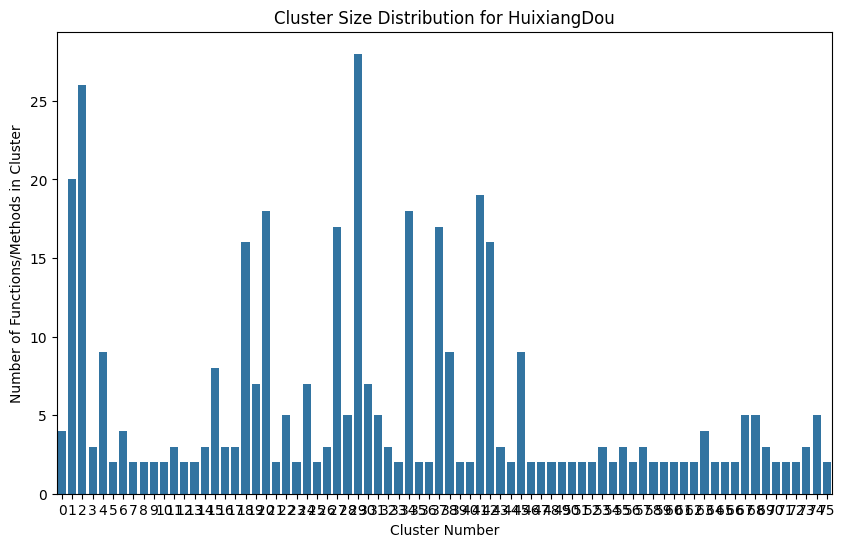

../../repos/cloned_repos/ai-goat/app/menu.py:16: SyntaxWarning: invalid escape sequence '\ '
  title = """
../../repos/cloned_repos/ai-goat/app/challenges/2/app.py:44: SyntaxWarning: invalid escape sequence '\/'
  regex_title = "<title>(.*)<\/title>"
../../repos/cloned_repos/ai-goat/app/menu.py:16: SyntaxWarning: invalid escape sequence '\ '
  title = """
../../repos/cloned_repos/ai-goat/app/challenges/2/app.py:44: SyntaxWarning: invalid escape sequence '\/'
  regex_title = "<title>(.*)<\/title>"
../../repos/cloned_repos/ai-goat/app/menu.py:16: SyntaxWarning: invalid escape sequence '\ '
  title = """
../../repos/cloned_repos/ai-goat/app/challenges/2/app.py:44: SyntaxWarning: invalid escape sequence '\/'
  regex_title = "<title>(.*)<\/title>"
../../repos/cloned_repos/ai-goat/app/menu.py:16: SyntaxWarning: invalid escape sequence '\ '
  title = """
../../repos/cloned_repos/ai-goat/app/challenges/2/app.py:44: SyntaxWarning: invalid escape sequence '\/'
  regex_title = "<title>(.*)<\/titl

Summary:
 - Repository analyzed    : ai-goat
 - Total Python files     : 8
 - Total Jupyter notebooks: 0
 - Functions/Methods found: 19
 - Classes found          : 3
 - Clusters found         : 7
✅ cluster_0.py saved with 1 entries
✅ cluster_1.py saved with 3 entries
✅ cluster_4.py saved with 1 entries
✅ cluster_5.py saved with 1 entries
✅ cluster_6.py saved with 1 entries
✅ cluster_3.py saved with 1 entries
✅ cluster_2.py saved with 3 entries

All cluster code files are in: result/repo_callgraph_clusters/ai-goat


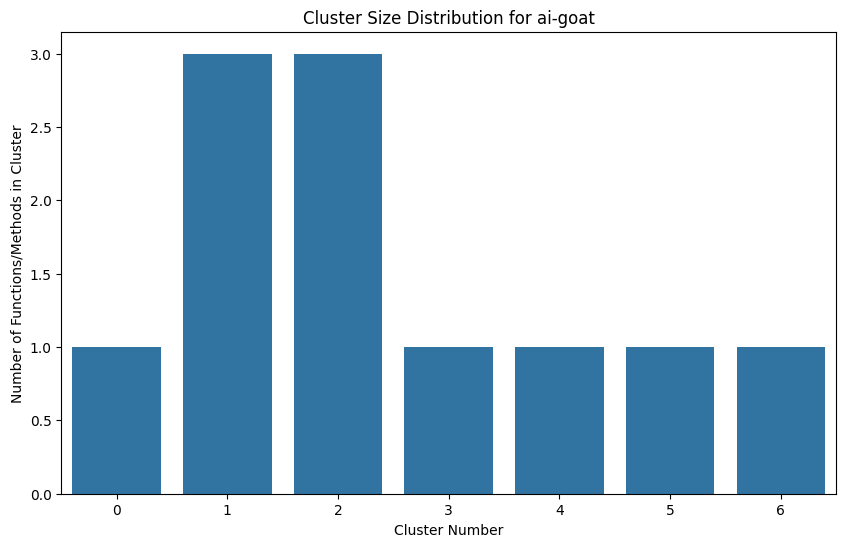

../../repos/cloned_repos/AgentBench/src/server/tasks/os_interaction/task.py:82: SyntaxWarning: invalid escape sequence '\['
  output = re.sub(b'\x1b\[\?2004[hl]', b'', output)
../../repos/cloned_repos/AgentBench/src/server/tasks/os_interaction/task.py:82: SyntaxWarning: invalid escape sequence '\['
  output = re.sub(b'\x1b\[\?2004[hl]', b'', output)


Summary:
 - Repository analyzed    : AgentBench
 - Total Python files     : 83
 - Total Jupyter notebooks: 0
 - Functions/Methods found: 276
 - Classes found          : 81
 - Clusters found         : 21


../../repos/cloned_repos/AgentBench/src/server/tasks/os_interaction/task.py:82: SyntaxWarning: invalid escape sequence '\['
  output = re.sub(b'\x1b\[\?2004[hl]', b'', output)
../../repos/cloned_repos/AgentBench/src/server/tasks/os_interaction/task.py:82: SyntaxWarning: invalid escape sequence '\['
  output = re.sub(b'\x1b\[\?2004[hl]', b'', output)


✅ cluster_0.py saved with 22 entries
✅ cluster_1.py saved with 8 entries
✅ cluster_2.py saved with 2 entries
✅ cluster_3.py saved with 3 entries
✅ cluster_4.py saved with 4 entries
✅ cluster_5.py saved with 10 entries
✅ cluster_8.py saved with 3 entries
✅ cluster_9.py saved with 5 entries
✅ cluster_12.py saved with 1 entries
✅ cluster_7.py saved with 3 entries
✅ cluster_14.py saved with 1 entries
✅ cluster_15.py saved with 1 entries
✅ cluster_16.py saved with 1 entries
✅ cluster_17.py saved with 2 entries
✅ cluster_18.py saved with 4 entries
✅ cluster_19.py saved with 4 entries
✅ cluster_20.py saved with 3 entries
✅ cluster_13.py saved with 1 entries
✅ cluster_6.py saved with 4 entries
✅ cluster_10.py saved with 3 entries
✅ cluster_11.py saved with 2 entries

All cluster code files are in: result/repo_callgraph_clusters/AgentBench


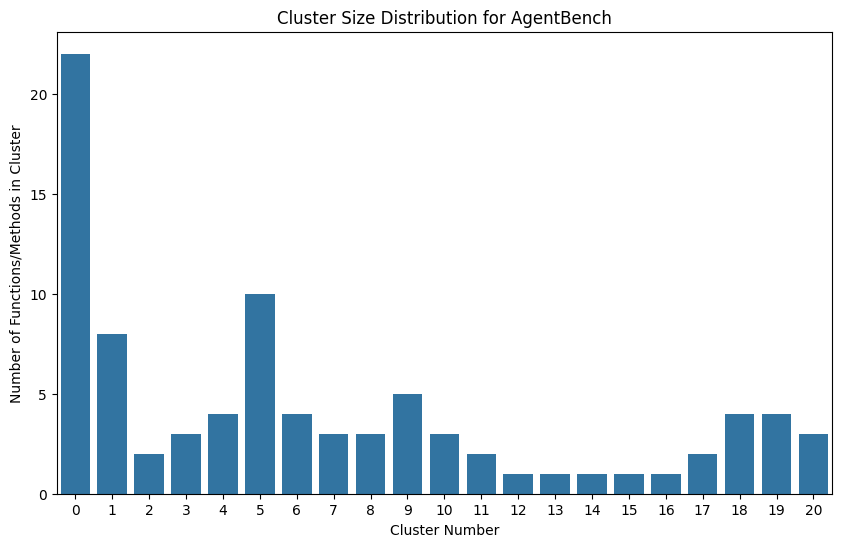

In [11]:
for repo_dir in ["/HuixiangDou","/ai-goat","/AgentBench"]:
    plot_cluster_size_distribution("../../repos/cloned_repos"+repo_dir)

In [115]:
all_functions

{'./rag-app/retriever.py:retrieve_context': <ast.FunctionDef at 0x70d616ad8350>,
 './rag-app/embedder.py:get_text_embedding': <ast.FunctionDef at 0x70d618046410>,
 './rag-app/vector_store.py:add_document': <ast.FunctionDef at 0x70d616c6a610>,
 './rag-app/vector_store.py:search_similar': <ast.FunctionDef at 0x70d617bde590>,
 './rag-app/rag_chain.py:generate_answer': <ast.FunctionDef at 0x70d617efafd0>}

In [123]:
for i in clusters.keys():
    print(f"Cluster {i}: {len(clusters[i])} functions/methods")

    print("Functions/Methods in Cluster:")
    not_in_files = set(clusters[i])

    for j in all_classes.keys():
        j = j.replace(repo_dir+"/","")
        if j in clusters[i]:
            not_in_files.discard(j)
            print(f"  - {j}")
    for j in all_functions.keys():
        j = j.replace(repo_dir+"/","")
        if j in clusters[i]:
            not_in_files.discard(j)
            print(f"  - {j}")
    
    print("Not found in collected definitions:")
    for item in not_in_files:
        print(f"  - {item}")

    print("Full Cluster Content:")
    for item in clusters[i]:
        print(f"  - {item}")
    print("-" * 60)

Cluster 0: 3 functions/methods
Functions/Methods in Cluster:
  - retriever.py:retrieve_context
  - rag_chain.py:generate_answer
Not found in collected definitions:
  - config.py:GenerativeModel
Full Cluster Content:
  - retriever.py:retrieve_context
  - rag_chain.py:generate_answer
  - config.py:GenerativeModel
------------------------------------------------------------
Cluster 1: 2 functions/methods
Functions/Methods in Cluster:
  - vector_store.py:search_similar
Not found in collected definitions:
  - config.py:query
Full Cluster Content:
  - vector_store.py:search_similar
  - config.py:query
------------------------------------------------------------
Cluster 2: 4 functions/methods
Functions/Methods in Cluster:
  - embedder.py:get_text_embedding
  - vector_store.py:add_document
Not found in collected definitions:
  - config.py:embed_content
  - config.py:upsert
Full Cluster Content:
  - embedder.py:get_text_embedding
  - config.py:embed_content
  - vector_store.py:add_document
  - 

In [ ]:
cluster_and_save_code("./rag-app")

retriever.py:retrieve_context vector_store.py:search_similar
embedder.py:get_text_embedding config.py:embed_content
vector_store.py:add_document embedder.py:get_text_embedding
vector_store.py:add_document config.py:upsert
vector_store.py:search_similar embedder.py:get_text_embedding
vector_store.py:search_similar config.py:query
rag_chain.py:generate_answer retriever.py:retrieve_context
rag_chain.py:generate_answer config.py:GenerativeModel
Graph with 9 nodes and 8 edges
✅ cluster_0.py saved with 3 entries
✅ cluster_1.py saved with 2 entries
✅ cluster_2.py saved with 4 entries

All cluster code files are in: result/repo_callgraph_clusters/rag-app


In [74]:
clusters[1]

['./monkey-net/train.py:split_kp',
 'detach',
 'items',
 './monkey-net/train.py:GeneratorFullModel.forward',
 'kp_extractor',
 'generator',
 'split_kp',
 'discriminator',
 'update',
 'generator_loss',
 'tuple',
 './monkey-net/train.py:DiscriminatorFullModel.forward',
 'discriminator_loss',
 'kp_detector',
 './monkey-net/frames_dataset.py:PairedDataset.__getitem__',
 './monkey-net/transfer.py:transfer_one',
 'cat_dict',
 'normalize_kp']